<a href="https://colab.research.google.com/github/Kornieks/Templates/blob/main/Data_Cleaning_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data cleaning template
Data cleaning involves identifying and removing any missing, duplicate or irrelevant data.

## Step 1 - Import Libraries and Load Dataset

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from google.colab import files

In [35]:
# upload dataset from your device
uploaded = files.upload()

Saving ai_skepticism_dataset.csv to ai_skepticism_dataset (1).csv


In [36]:
# transform csv format to a 'table' format
df = pd.read_csv('ai_skepticism_dataset.csv')

In [37]:
# get familiar with data
df.head()

,ai_model_name,query_category,ai_confidence_percentage,response_character_count,has_cited_sources,contains_hedging_words,includes_disclaimer,answer_detail_level,respondent_age_bracket,education_level,...,urgency_level,belief_alignment_status,subject_matter_expertise,trust_score_out_of_10,performed_fact_check,fact_check_method_used,verification_duration_mins,answer_accuracy_percentage,trust_calibration_valid,user_skepticism_category
0,Claude,math_calculation,93.23,527,True,False,False,Moderate,45-54,Bachelors,...,Low,False,False,10.0,True,Google Search,10.7,80.15,True,Moderate Trust
1,Llama,recipe_cooking,84.47,581,False,False,False,Specific,55-64,PhD,...,NaN,False,True,7.9,True,Asked Expert,44.3,92.33,True,Skeptical
2,Claude,general_knowledge,69.82,484,True,True,False,Very Specific,35-44,High School,...,NaN,True,False,8.6,True,Consulted Documentation,37.5,67.32,True,Moderate Trust
3,Claude,creative_writing,79.61,73,True,True,False,Specific,45-54,Professional,...,NaN,NaN,False,8.9,True,Checked Official Source,22.7,73.12,True,Moderate Trust
4,Claude,creative_writing,67.71,146,False,True,False,Vague,55-64,Masters,...,NaN,True,True,9.0,True,Academic Paper,43.7,81.05,True,Moderate Trust


Make sure you understand what each column means. I would suggest creating additional file with definitions.

## Step 2 - work with datatypes

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ai_model_name               1000 non-null   object 
 1   query_category              1000 non-null   object 
 2   ai_confidence_percentage    1000 non-null   float64
 3   response_character_count    1000 non-null   int64  
 4   has_cited_sources           1000 non-null   bool   
 5   contains_hedging_words      1000 non-null   bool   
 6   includes_disclaimer         1000 non-null   bool   
 7   answer_detail_level         1000 non-null   object 
 8   respondent_age_bracket      1000 non-null   object 
 9   education_level             1000 non-null   object 
 10  digital_literacy_score      1000 non-null   object 
 11  ai_familiarity_level        1000 non-null   object 
 12  decision_importance         1000 non-null   object 
 13  urgency_level               779 no

It is important to check:
* dtype accuracy
* missing values (Non-Null Count)
* column names

In [39]:
# see the number of rows and columns
df.shape

(1000, 23)

In [40]:
# identify column data types
# use list comprehension with .dtype attribute to separate columns
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype == 'int' or df[col].dtype == 'float']
bool_col = [col for col in df.columns if df[col].dtype == 'bool']
date_col = [col for col in df.columns if df[col].dtype == 'datetime64']

# let's make sure we didn't skip any column
classified_col = cat_col + num_col + bool_col + date_col
other_col = [col for col in df.columns if col not in classified_col]

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)
print('Boolean columns:', bool_col)
print('Date columns:', date_col)
print('Other columns:', date_col)


Categorical columns: ['ai_model_name', 'query_category', 'answer_detail_level', 'respondent_age_bracket', 'education_level', 'digital_literacy_score', 'ai_familiarity_level', 'decision_importance', 'urgency_level', 'belief_alignment_status', 'fact_check_method_used', 'user_skepticism_category']
Numerical columns: ['ai_confidence_percentage', 'response_character_count', 'trust_score_out_of_10', 'verification_duration_mins', 'answer_accuracy_percentage']
Boolean columns: ['has_cited_sources', 'contains_hedging_words', 'includes_disclaimer', 'subject_matter_expertise', 'performed_fact_check', 'trust_calibration_valid']
Date columns: []
Other columns: []


Columns that contain text data could also be non-categorical (e.g. job description). It is important to differentiate between those.

In [41]:
# you can also use this sanity-check to confirm you've accounted for every column
# you will see an error if something is wrong

assert len(cat_col) + len(num_col) + len(bool_col) + len(date_col) + len(other_col) == len(df.columns)

In this dataset, all columns datatypes are identified appropriately.

**However, it is important to
change datatype where needed:**

* `df['col'] = df['col'].astype('int64')` - to integer
* `df['col'] = pd.to_datetime(df['col'])` - to datatime
* `df['col'] = df['col'].astype('str')` -  or 'object' - to text

## Step 3 - Identify and Fill in Missing Values

In [42]:
# df.isnull will return a boolean Series indicating duplicate rows
# use sum to see the number of rows with missing values in each column
df.isnull().sum()

,0
ai_model_name,0
query_category,0
ai_confidence_percentage,0
response_character_count,0
has_cited_sources,0
contains_hedging_words,0
includes_disclaimer,0
answer_detail_level,0
respondent_age_bracket,0
education_level,0


In [44]:
# calculate missing values as percentage
# df.shape[0] - total number of rows
# round ( _ , 2) returns number rounded to 2 decimal points
round(df.isnull().sum() * 100 / df.shape[0], 2)

,0
ai_model_name,0.0
query_category,0.0
ai_confidence_percentage,0.0
response_character_count,0.0
has_cited_sources,0.0
contains_hedging_words,0.0
includes_disclaimer,0.0
answer_detail_level,0.0
respondent_age_bracket,0.0
education_level,0.0


**Now, we have to decide what we will do with missing values:**

* leave as-is (if the model/methods handles NaN natively)

* fill with a statistical measure (mean, median, mode) - I usually do this with numerical columns.

`df['col'].fillna(df['col'].mean(), inplace=True)`
* fill with a constant (e.g. 'unknown' or 'not specified')

`df[cat_col] = df[cat_col].fillna('Not Specified')`

* drop rows/columns with missing values

*When to drop rows* — missing values are random, small percentage of dataset (typically <5%), and losing them won't bias the data.

`df.dropna()`

*When to drop columns* — the column has too many missing values (typically >50%) and can't be reliably filled.

`df.drop(columns=['col1', 'col2'])`



In [45]:
print(df['urgency_level'].unique()) # look at unique values
df[df['urgency_level'].isna()] # look at rows with missing values

['Low' nan 'High' 'Medium']


,ai_model_name,query_category,ai_confidence_percentage,response_character_count,has_cited_sources,contains_hedging_words,includes_disclaimer,answer_detail_level,respondent_age_bracket,education_level,...,urgency_level,belief_alignment_status,subject_matter_expertise,trust_score_out_of_10,performed_fact_check,fact_check_method_used,verification_duration_mins,answer_accuracy_percentage,trust_calibration_valid,user_skepticism_category
1,Llama,recipe_cooking,84.47,581,False,False,False,Specific,55-64,PhD,...,NaN,False,True,7.9,True,Asked Expert,44.3,92.33,True,Skeptical
2,Claude,general_knowledge,69.82,484,True,True,False,Very Specific,35-44,High School,...,NaN,True,False,8.6,True,Consulted Documentation,37.5,67.32,True,Moderate Trust
3,Claude,creative_writing,79.61,73,True,True,False,Specific,45-54,Professional,...,NaN,NaN,False,8.9,True,Checked Official Source,22.7,73.12,True,Moderate Trust
4,Claude,creative_writing,67.71,146,False,True,False,Vague,55-64,Masters,...,NaN,True,True,9.0,True,Academic Paper,43.7,81.05,True,Moderate Trust
5,Mistral,math_calculation,93.41,198,False,True,False,Moderate,18-24,Professional,...,NaN,False,False,8.2,False,NaN,0.0,100.00,True,Blind Trust
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
983,ChatGPT-3.5,math_calculation,98.00,122,False,True,False,Vague,45-54,Professional,...,NaN,NaN,False,10.0,True,Personal Testing,20.3,86.65,True,Moderate Trust
985,Gemini,legal_advice,49.05,241,False,True,False,Very Specific,35-44,Bachelors,...,NaN,NaN,False,4.6,True,Google Search,40.6,39.11,True,Highly Skeptical
990,Gemini,technical_coding,78.94,705,False,True,True,Vague,18-24,High School,...,NaN,False,False,6.2,True,Personal Testing,41.6,77.88,True,Skeptical
997,Claude,technical_coding,77.38,166,True,True,False,Specific,35-44,High School,...,NaN,True,True,10.0,True,Cross-referenced Multiple AIs,23.3,92.14,True,Moderate Trust


In [46]:
print(df['fact_check_method_used'].unique())
df[df['fact_check_method_used'].isna()]

['Google Search' 'Asked Expert' 'Consulted Documentation'
 'Checked Official Source' 'Academic Paper' nan 'Personal Testing'
 'Cross-referenced Multiple AIs' 'Asked Colleague']


,ai_model_name,query_category,ai_confidence_percentage,response_character_count,has_cited_sources,contains_hedging_words,includes_disclaimer,answer_detail_level,respondent_age_bracket,education_level,...,urgency_level,belief_alignment_status,subject_matter_expertise,trust_score_out_of_10,performed_fact_check,fact_check_method_used,verification_duration_mins,answer_accuracy_percentage,trust_calibration_valid,user_skepticism_category
5,Mistral,math_calculation,93.41,198,False,True,False,Moderate,18-24,Professional,...,NaN,False,False,8.2,False,NaN,0.0,100.00,True,Blind Trust
6,Claude,technical_coding,75.87,285,False,False,True,Very Specific,18-24,High School,...,High,False,True,7.6,False,NaN,0.0,79.04,True,Moderate Trust
7,Claude,financial_advice,57.32,371,True,False,False,Vague,55-64,Professional,...,High,NaN,False,6.4,False,NaN,0.0,55.65,True,Moderate Trust
11,Claude,recipe_cooking,76.69,70,True,False,True,Moderate,18-24,Professional,...,Medium,NaN,True,9.9,False,NaN,0.0,62.11,False,Blind Trust
14,Gemini,creative_writing,75.00,386,False,True,True,Moderate,45-54,Professional,...,Medium,True,False,9.9,False,NaN,0.0,66.21,False,Blind Trust
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
986,ChatGPT-3.5,scientific_facts,81.39,410,True,True,False,Specific,18-24,Masters,...,Low,NaN,False,9.1,False,NaN,0.0,79.82,True,Blind Trust
987,Claude,financial_advice,51.91,403,True,True,True,Vague,65+,High School,...,High,False,False,3.5,False,NaN,0.0,43.51,True,Skeptical
988,Llama,recipe_cooking,78.80,449,True,False,False,Vague,65+,High School,...,Low,True,False,10.0,False,NaN,0.0,84.44,True,Blind Trust
995,Gemini,math_calculation,94.09,661,True,True,False,Specific,35-44,Masters,...,High,True,True,10.0,False,NaN,0.0,95.33,True,Blind Trust


In [47]:
print(df['belief_alignment_status'].unique())
df[df['belief_alignment_status'].isna()]

[False True nan]


,ai_model_name,query_category,ai_confidence_percentage,response_character_count,has_cited_sources,contains_hedging_words,includes_disclaimer,answer_detail_level,respondent_age_bracket,education_level,...,urgency_level,belief_alignment_status,subject_matter_expertise,trust_score_out_of_10,performed_fact_check,fact_check_method_used,verification_duration_mins,answer_accuracy_percentage,trust_calibration_valid,user_skepticism_category
3,Claude,creative_writing,79.61,73,True,True,False,Specific,45-54,Professional,...,NaN,NaN,False,8.9,True,Checked Official Source,22.7,73.12,True,Moderate Trust
7,Claude,financial_advice,57.32,371,True,False,False,Vague,55-64,Professional,...,High,NaN,False,6.4,False,NaN,0.0,55.65,True,Moderate Trust
8,ChatGPT-3.5,medical_advice,50.17,344,False,False,True,Vague,65+,PhD,...,High,NaN,False,5.3,True,Personal Testing,20.0,41.69,True,Skeptical
10,Claude,general_knowledge,82.85,331,True,True,True,Specific,45-54,Masters,...,Medium,NaN,True,10.0,True,Academic Paper,22.9,68.05,False,Moderate Trust
11,Claude,recipe_cooking,76.69,70,True,False,True,Moderate,18-24,Professional,...,Medium,NaN,True,9.9,False,NaN,0.0,62.11,False,Blind Trust
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
980,GPT-4,current_events,59.40,324,False,False,True,Specific,18-24,Bachelors,...,NaN,NaN,True,6.4,False,NaN,0.0,49.86,True,Moderate Trust
983,ChatGPT-3.5,math_calculation,98.00,122,False,True,False,Vague,45-54,Professional,...,NaN,NaN,False,10.0,True,Personal Testing,20.3,86.65,True,Moderate Trust
985,Gemini,legal_advice,49.05,241,False,True,False,Very Specific,35-44,Bachelors,...,NaN,NaN,False,4.6,True,Google Search,40.6,39.11,True,Highly Skeptical
986,ChatGPT-3.5,scientific_facts,81.39,410,True,True,False,Specific,18-24,Masters,...,Low,NaN,False,9.1,False,NaN,0.0,79.82,True,Blind Trust


I will fill NaN with 'Not Specified' in columns `urgency_level` and `fact_check_method_used`.
These columns are categorical and the absence of a value is itself meaningful —
it indicates the respondent did not provide this information rather than it being
missing at random. Replacing with 'Not Specified' preserves this signal instead
of dropping the rows or making assumptions about the true value.

In [48]:
df['urgency_level'] = df['urgency_level'].fillna('Not Specified')
df['fact_check_method_used'] = df['fact_check_method_used'].fillna('Not Specified')

Based on the name and values, column `belief_alignment_status` likely indicates whether a respondent's personal beliefs align with a particular AI-related position or stance being measured in the survey.
The NaN values could suggest they skipped the question.

They likely represent genuine uncertainty or refusal to answer, so dropping them might not be the best choice. Filling with False or mode could also be misleading. It may be worth keeping NaN as a separate category meaning "undecided".

In [49]:
df['belief_alignment_status'] = df['belief_alignment_status'].fillna('Not specified')

In [50]:
# check
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ai_model_name               1000 non-null   object 
 1   query_category              1000 non-null   object 
 2   ai_confidence_percentage    1000 non-null   float64
 3   response_character_count    1000 non-null   int64  
 4   has_cited_sources           1000 non-null   bool   
 5   contains_hedging_words      1000 non-null   bool   
 6   includes_disclaimer         1000 non-null   bool   
 7   answer_detail_level         1000 non-null   object 
 8   respondent_age_bracket      1000 non-null   object 
 9   education_level             1000 non-null   object 
 10  digital_literacy_score      1000 non-null   object 
 11  ai_familiarity_level        1000 non-null   object 
 12  decision_importance         1000 non-null   object 
 13  urgency_level               1000 n

# Step 4 - Check for Duplicates and Drop them
including rows, values, possible mistakes

In [51]:
# identify duplicated rows

print(f'The number of duplicated rows: {df.duplicated().sum()}')

The number of duplicated rows: 0


There could be duplicated rows because of inconsistent register or spaces. Let's check it

In [52]:
# look for hidden duplicates
df_clean = df.copy()
df_clean = df_clean.apply(lambda val: val.str.strip().str.lower() if val.dtype == 'object' else val)

print(f'The number of hidden duplicated rows: {df_clean.duplicated().sum()}')

The number of hidden duplicated rows: 0


If you found duplicated rows, drop them using this syntax:
`df.drop_duplicates()` .

Don't forget to save any changes by `df =`.

There also could be duplicated categorical values because of typos or inconsistent formatting
(e.g. 'USA', 'usa', 'U.S.A' all meaning the same thing). Lowercasing and stripping
whitespace helps, but it's worth checking unique values manually for each categorical column.


In [53]:
for col in cat_col:
  print(f"\n{col}:", df[col].unique())


ai_model_name: ['Claude' 'Llama' 'Mistral' 'ChatGPT-3.5' 'Gemini' 'GPT-4']

query_category: ['math_calculation' 'recipe_cooking' 'general_knowledge'
 'creative_writing' 'technical_coding' 'financial_advice' 'medical_advice'
 'current_events' 'factual_historical' 'opinion_based' 'legal_advice'
 'scientific_facts']

answer_detail_level: ['Moderate' 'Specific' 'Very Specific' 'Vague']

respondent_age_bracket: ['45-54' '55-64' '35-44' '18-24' '65+' '25-34']

education_level: ['Bachelors' 'PhD' 'High School' 'Professional' 'Masters']

digital_literacy_score: ['Low' 'Expert' 'Medium' 'High']

ai_familiarity_level: ['Intermediate' 'First Time' 'Advanced' 'Expert' 'Beginner']

decision_importance: ['Low' 'High' 'Critical' 'Medium']

urgency_level: ['Low' 'Not Specified' 'High' 'Medium']

belief_alignment_status: [False True 'Not specified']

fact_check_method_used: ['Google Search' 'Asked Expert' 'Consulted Documentation'
 'Checked Official Source' 'Academic Paper' 'Not Specified'
 'Personal 

In [54]:
# see unique values in all columns
df.nunique()

,0
ai_model_name,6
query_category,12
ai_confidence_percentage,908
response_character_count,541
has_cited_sources,2
contains_hedging_words,2
includes_disclaimer,2
answer_detail_level,4
respondent_age_bracket,6
education_level,5


In this dataset, there is no need for changing any values. However, here is an example how may do it:

`df['col'] = df['col'].replace('mEdIUm', 'Medium')`

Sometimes there may be duplicate IDs with slight differences in other columns.
Use this to inspect them side by side and spot where they differ:

`df.duplicated(subset=[id]).sum()` - to see number of duplicates
`df[df.duplicated(subset=[id], keep=False)].sort_values(by='id').T` - to see rows with duplicated id and compare what is different

In [55]:
# example from this dataset (* duplicates is okay for this value)

df[df.duplicated(subset=['answer_accuracy_percentage'], keep=False)].sort_values(by='answer_accuracy_percentage').T

,210,831,361,276,522,621,716,194,400,373,...,521,768,781,837,720,892,890,935,975,998
ai_model_name,Llama,Gemini,Llama,Llama,Mistral,GPT-4,Claude,GPT-4,GPT-4,Mistral,...,Claude,Gemini,Llama,GPT-4,Llama,Claude,Mistral,ChatGPT-3.5,Claude,ChatGPT-3.5
query_category,opinion_based,medical_advice,legal_advice,opinion_based,financial_advice,current_events,medical_advice,current_events,opinion_based,legal_advice,...,factual_historical,factual_historical,math_calculation,math_calculation,factual_historical,math_calculation,math_calculation,technical_coding,math_calculation,math_calculation
ai_confidence_percentage,53.48,53.74,45.19,48.79,40.85,59.65,58.83,60.97,52.74,54.51,...,94.5,90.32,92.18,90.05,86.02,96.17,97.43,93.53,92.33,98.61
response_character_count,146,94,586,435,735,739,724,622,515,784,...,549,147,311,208,665,285,409,146,53,71
has_cited_sources,False,False,True,True,True,False,False,True,True,True,...,False,True,False,False,True,True,False,True,False,False
contains_hedging_words,True,True,True,False,False,False,True,True,False,False,...,True,True,True,False,False,False,False,False,False,True
includes_disclaimer,True,False,True,False,False,False,True,True,False,True,...,False,False,True,False,True,True,False,False,False,False
answer_detail_level,Vague,Moderate,Vague,Vague,Moderate,Very Specific,Vague,Very Specific,Moderate,Specific,...,Specific,Vague,Specific,Moderate,Moderate,Very Specific,Moderate,Very Specific,Very Specific,Very Specific
respondent_age_bracket,55-64,45-54,35-44,18-24,35-44,35-44,55-64,45-54,35-44,18-24,...,35-44,25-34,55-64,55-64,18-24,18-24,65+,25-34,18-24,25-34
education_level,Bachelors,High School,Masters,Bachelors,Professional,Professional,Masters,High School,Masters,High School,...,Bachelors,High School,High School,PhD,Bachelors,PhD,PhD,Masters,Professional,High School


Decide what to do with duplicated IDs if there are any.

## Step 5 - Drop Irrelevant or Data-Heavy Missing Columns


Not all columns are worth keeping. A column should be dropped if:
- it has too many missing values (typically >50%) and can't be reliably filled
- it doesn't contribute to the analysis or model (administrative info, free-text notes)
- it is redundant — the same information exists in another column

This step reduces noise and keeps the dataset focused on what matters.

Let's imagine we don't need this column `contains_hedging_words`

In [56]:
# drop specified columns
# inplace=True means the change is applied directly to the original dataframe without needing to reassign it
df.drop(columns=['contains_hedging_words'], inplace=True)

# Step 6 - Detect Outliers

In [57]:
# get a statistical summary
df.describe()

,ai_confidence_percentage,response_character_count,trust_score_out_of_10,verification_duration_mins,answer_accuracy_percentage
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,72.006790,429.022000,7.905000,14.840000,69.982020
std,14.663334,221.644937,1.766866,15.182336,18.176782
min,40.520000,50.000000,1.800000,0.000000,19.420000
25%,60.570000,239.500000,6.700000,0.000000,58.570000
50%,74.235000,423.000000,8.200000,11.050000,72.080000
75%,83.862500,629.000000,9.500000,28.200000,83.140000
max,98.660000,799.000000,10.000000,45.000000,100.000000


**Pay attention to:**
* big gap between max/min and the 75%/25% values suggests outliers
* mean and median (50%) are very different — data is skewed

* min is negative when it shouldn't be (e.g. age, price)
* max seems unrealistically high
* something doesn't make sense for the domain

* count is lower than expected — means there are NaNs
* std is 0 or very close to 0 — column has almost no variation and may not be useful

In [58]:
# oulier detection with IQR method
# since we have several numerical columns, it is logical to create a function

def iqr_outlier_detection(df, col):
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)

  iqr = q3 - q1

  lower_bound = q1 - iqr * 1.5
  upper_bound = q3 + iqr * 1.5

  outliers = df[(df[col] < lower_bound) | df[col] > upper_bound]

  print(f'Number of possible outliers, according to the IQR method in {col}: {outliers.shape[0]}, {round(outliers.shape[0]*100/df.shape[0],2)}%')


In [59]:
for col in num_col:
   iqr_outlier_detection(df, col)


Number of possible outliers, according to the IQR method in ai_confidence_percentage: 0, 0.0%
Number of possible outliers, according to the IQR method in response_character_count: 0, 0.0%
Number of possible outliers, according to the IQR method in trust_score_out_of_10: 0, 0.0%
Number of possible outliers, according to the IQR method in verification_duration_mins: 0, 0.0%
Number of possible outliers, according to the IQR method in answer_accuracy_percentage: 0, 0.0%


In [60]:
# oulier detection with Z-score method
# since we have several numerical columns, it is logical to create a function

def z_outlier_detection(df, col):
   mean = df[col].mean()
   std = df[col].std()

   z_scores = (df[col] - mean) / std

   outliers_z = df[abs(z_scores) > 3]


   print(f'Number of possible outliers, according to the Z_score analysis in {col}: {outliers_z.shape[0]}, {round(outliers_z.shape[0]*100/df.shape[0],2)}%')
   return outliers_z


`z_scores = np.abs(stats.zscore(df['product_price'], nan_policy = 'omit'))`
- another syntax you can use

In [61]:
for col in num_col:
   z_outlier_detection(df, col)


Number of possible outliers, according to the Z_score analysis in ai_confidence_percentage: 0, 0.0%
Number of possible outliers, according to the Z_score analysis in response_character_count: 0, 0.0%
Number of possible outliers, according to the Z_score analysis in trust_score_out_of_10: 3, 0.3%
Number of possible outliers, according to the Z_score analysis in verification_duration_mins: 0, 0.0%
Number of possible outliers, according to the Z_score analysis in answer_accuracy_percentage: 0, 0.0%


In [62]:
# manually check
outliers = z_outlier_detection(df, 'trust_score_out_of_10').T
print(outliers)

Number of possible outliers, according to the Z_score analysis in trust_score_out_of_10: 3, 0.3%
                                         218               299  \
ai_model_name                    ChatGPT-3.5            Gemini   
query_category                 opinion_based  financial_advice   
ai_confidence_percentage               41.66             44.99   
response_character_count                 782               405   
has_cited_sources                      False             False   
includes_disclaimer                    False              True   
answer_detail_level                    Vague             Vague   
respondent_age_bracket                 45-54               65+   
education_level                 Professional       High School   
digital_literacy_score                  High            Expert   
ai_familiarity_level            Intermediate            Expert   
decision_importance                     High          Critical   
urgency_level                            Low 

**Remove outliers when:**

* they are clearly data entry errors (e.g. age = 999, price = -50)
* they are a tiny percentage of the dataset and random
* you are using a model sensitive to outliers (e.g. linear regression, KNN, K-means)

**Keep outliers when:**

* they are rare but valid data points (e.g. a billionaire in an income dataset)
* the outlier is exactly what you're trying to detect (e.g. fraud detection)
* you are using a model robust to outliers (e.g. tree-based models like XGBoost, Random Forest)

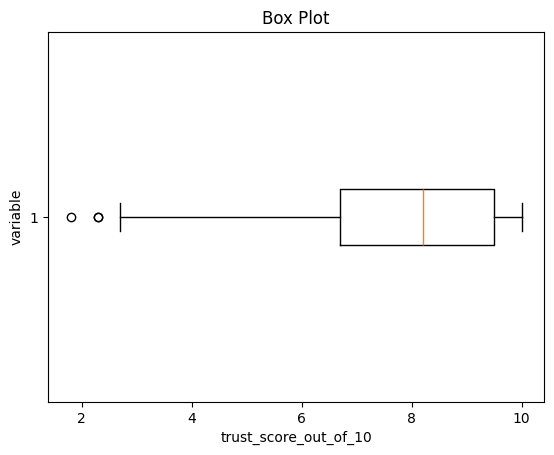

In [63]:
# you can also use box plot to visualize outliers

plt.boxplot(df['trust_score_out_of_10'], vert=False)
plt.ylabel('variable')
plt.xlabel('trust_score_out_of_10')
plt.title('Box Plot')
plt.show()